# Logistic Regression Meta-Model

This notebook mirrors the Random Forest workflow for a linear meta-model:

1. Load one instrument's clean feature set and saved triple-barrier labels.
2. Build train/OOS modelling tables for every triple-barrier configuration.
3. Run CPCV grid search for L2, L1, and Elastic Net logistic regression.
4. Rank candidates by mean CPCV AUC, then inspect Sharpe across CPCV splits for the top candidates.
5. Fit the selected model on the full training period, evaluate OOS, compare against the primary-signal baseline, and save outputs.

The target is always `metalabel`. The primary signal remains a feature because the meta-model learns when to take the primary trade, not trade direction from scratch.


In [1]:
from __future__ import annotations

from pathlib import Path
from itertools import combinations
import copy
import json
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "features").exists() and (candidate / "03_model_development").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with data/features and 03_model_development.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
FEATURE_SELECTION_DIR = PROJECT_ROOT / "03_model_development" / "Feature Selection"
if str(FEATURE_SELECTION_DIR) not in sys.path:
    sys.path.insert(0, str(FEATURE_SELECTION_DIR))

from feature_selection_methods import (  # noqa: E402
    CorrelationClusterResult,
    CorrelationClusterSelector,
    DEFAULT_EXCLUDE_COLUMNS,
    PCAFeatureReducer,
    PCAFeatureReductionResult,
    infer_numeric_feature_columns,
    run_correlation_cluster_selection,
    run_pca_feature_reduction,
)

print("Project root:", PROJECT_ROOT)
print("Feature-selection utilities imported from:", FEATURE_SELECTION_DIR)


Project root: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw
Feature-selection utilities imported from: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/03_model_development/Feature Selection


## 1. Settings

Keep `RUN_FULL_GRID = False` while checking the notebook. Set it to `True` for the full coursework run.


In [ ]:
# Energy tickers to run. Full search evaluates every triple-barrier config for each ticker.
TICKERS = ["cl1s", "ho1s", "rb1s", "ng1s"]
TICKER = TICKERS[0]  # Used only for quick previews/examples.

# Full mode uses every selected ticker, every TB config, and the full logistic grid.
RUN_FULL_GRID = True
SMOKE_CONFIG_NAMES = ["ewma_10d_tp2_sl2"]

# Clean out-of-sample period. Model selection/CPCV uses only rows before TEST_START_DATE.
TEST_START_DATE = "2022-01-01"
TEST_END_DATE = "2022-06-30"

DATE_COL = "date"
INSTRUMENT_COL = "instrument"
TARGET_COL = "metalabel"
TRAIN_ON_NONZERO_SIGNALS_ONLY = True

CPCV_N_BLOCKS = 8
CPCV_N_TEST_BLOCKS = 2

# Logistic preprocessing.
FEATURE_CLIP_LOWER = 0.01
FEATURE_CLIP_UPPER = 0.99
FEATURE_ABS_CAP = 1_000_000.0

# Full logistic grid.
FULL_C_VALUES = [0.1, 1.0]
FULL_ELASTIC_L1_RATIOS = [0.5]

# Smaller smoke grid.
SMOKE_C_VALUES = [0.1]
SMOKE_ELASTIC_L1_RATIOS = [0.5]

C_VALUES = FULL_C_VALUES if RUN_FULL_GRID else SMOKE_C_VALUES
ELASTIC_L1_RATIOS = FULL_ELASTIC_L1_RATIOS if RUN_FULL_GRID else SMOKE_ELASTIC_L1_RATIOS

SAVE_DETAILED_OUTPUTS = True

print("Tickers:", TICKERS)
print("Run full grid:", RUN_FULL_GRID)
print("C values:", C_VALUES)
print("Elastic Net l1 ratios:", ELASTIC_L1_RATIOS)


Tickers: ['cl1s', 'ho1s', 'rb1s', 'ng1s']
Run full grid: True
C values: [0.1, 1.0]
Elastic Net l1 ratios: [0.25, 0.5, 0.75]


## 2. Paths And Non-Feature Columns

Triple-barrier metadata stays in the dataframe for CPCV, thresholds, and strategy diagnostics. It is explicitly excluded from model features.


In [3]:
CLEAN_FEATURE_DIR = PROJECT_ROOT / "data" / "features" / "clean_feature_set"
TRIPLE_BARRIER_DIR = PROJECT_ROOT / "data" / "features" / "triple_barrier"
TRIPLE_BARRIER_SUMMARY_PATH = TRIPLE_BARRIER_DIR / "triple_barrier_config_summary.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "data" / "model_outputs" / "logistic_regression"
RESULTS_DIR = PROJECT_ROOT / "results"
LOGISTIC_RESULTS_PATH = RESULTS_DIR / "logistic_regression.csv"
MODEL_COMPARISON_RESULTS_PATH = RESULTS_DIR / "model_comparison.csv"

# Columns that should never enter X. Some are kept for CPCV/evaluation only.
NON_FEATURE_COLS = {
    DATE_COL,
    INSTRUMENT_COL,
    TARGET_COL,
    "target",
    "label",
    "y",
    "meta_label",
    "tb_label",
    "barrier_label",
    "signal_column",
    "training_end",
    "num_days",
    "t1",
    "timeout_date",
    "timeout_close",
    "touch_date",
    "touch_price",
    "touched_barrier",
    "vertical_barrier_date",
    "barrier_touch_date",
    "event_end_date",
    "exit_date",
    "exit_price",
    "triple_barrier_label",
    "holding_period_days",
    "raw_touch_return",
    "signed_touch_return",
    "exit_return",
    "triple_barrier_return",
    "tb_return",
    "realised_return",
    "realized_return",
    "pnl",
    "profit",
    "barrier_touched",
    "first_barrier_touched",
    "hit_barrier",
    "pt",
    "sl",
    "tp",
    "pt_mult",
    "sl_mult",
    "take_profit_mult",
    "stop_loss_mult",
    "vol",
    "volatility",
    "target_vol",
    "volatility_method",
    "ewma_span",
    "volatility_window",
    "close_tb",
}

PROTECTED_FEATURES = ["primary_signal"]

print("Clean feature dir:", CLEAN_FEATURE_DIR)
print("Triple-barrier dir:", TRIPLE_BARRIER_DIR)
print("Output dir:", MODEL_OUTPUT_DIR)


Clean feature dir: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/data/features/clean_feature_set
Triple-barrier dir: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/data/features/triple_barrier
Output dir: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/data/model_outputs/logistic_regression


## 3. Load Clean Features And Triple-Barrier Labels

Only `metalabel` is the modelling target. Triple-barrier dates/returns are metadata for split logic and diagnostics.


In [4]:
def extract_num_days_from_filename(path: Path) -> int | None:
    filename = path.stem.lower()
    for pattern in [r"num_days[_\-]?(\d+)", r"(\d+)d", r"horizon[_\-]?(\d+)"]:
        match = re.search(pattern, filename)
        if match:
            return int(match.group(1))
    return None


def clean_feature_path_for_ticker(ticker: str) -> Path:
    return CLEAN_FEATURE_DIR / f"{ticker}_clean_feature_set.csv"


def load_feature_set(path: Path, ticker: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Feature set not found: {path}")

    features = pd.read_csv(path, parse_dates=[DATE_COL])
    if INSTRUMENT_COL in features.columns:
        features[INSTRUMENT_COL] = features[INSTRUMENT_COL].str.lower()
        features = features[features[INSTRUMENT_COL] == ticker.lower()].copy()

    features = features.sort_values(DATE_COL).reset_index(drop=True)
    if features.empty:
        raise ValueError(f"No clean feature rows found for {ticker}.")
    return features


def load_triple_barrier_files(triple_barrier_dir: Path, ticker: str) -> dict[str, pd.DataFrame]:
    if not triple_barrier_dir.exists():
        raise FileNotFoundError(f"Triple-barrier directory not found: {triple_barrier_dir}")

    csv_files = sorted(
        path for path in triple_barrier_dir.glob("*.csv")
        if ticker.lower() in path.name.lower() and path.name != "triple_barrier_config_summary.csv"
    )
    if not csv_files:
        raise FileNotFoundError(f"No triple-barrier CSV files found for {ticker} in {triple_barrier_dir}")

    selected_files = csv_files
    if not RUN_FULL_GRID:
        selected_files = [path for path in csv_files if path.stem.replace(f"{ticker.lower()}_", "") in SMOKE_CONFIG_NAMES]
        if not selected_files:
            raise ValueError(f"Smoke configs {SMOKE_CONFIG_NAMES} were not found for {ticker}.")

    tb_data = {}
    for path in selected_files:
        header = pd.read_csv(path, nrows=0).columns
        date_cols = [col for col in [DATE_COL, "training_end", "timeout_date", "touch_date"] if col in header]
        df = pd.read_csv(path, parse_dates=date_cols)
        df[DATE_COL] = pd.to_datetime(df[DATE_COL])

        if INSTRUMENT_COL in df.columns:
            df[INSTRUMENT_COL] = df[INSTRUMENT_COL].str.lower()
            df = df[df[INSTRUMENT_COL] == ticker.lower()].copy()

        if "num_days" in df.columns:
            num_days_values = pd.to_numeric(df["num_days"], errors="coerce").dropna()
            if num_days_values.empty:
                raise ValueError(f"num_days column is empty/non-numeric in {path.name}")
            num_days = int(num_days_values.mode().iloc[0])
        else:
            num_days = extract_num_days_from_filename(path)
            if num_days is None:
                raise ValueError(f"Could not infer num_days for {path.name}.")
            df["num_days"] = num_days

        if TARGET_COL not in df.columns:
            raise ValueError(f"{TARGET_COL} not found in {path.name}. Available columns: {list(df.columns)}")
        if "timeout_date" not in df.columns:
            raise ValueError(f"timeout_date not found in {path.name}; CPCV purging needs it.")
        if "signed_touch_return" not in df.columns:
            raise ValueError(f"signed_touch_return not found in {path.name}; strategy diagnostics need it.")

        keep_cols = [DATE_COL]
        if INSTRUMENT_COL in df.columns:
            keep_cols.append(INSTRUMENT_COL)
        for col in [
            TARGET_COL,
            "primary_signal",
            "num_days",
            "timeout_date",
            "touch_date",
            "signed_touch_return",
            "raw_touch_return",
            "triple_barrier_label",
            "touched_barrier",
            "holding_period_days",
        ]:
            if col in df.columns and col not in keep_cols:
                keep_cols.append(col)

        df = df[keep_cols].copy()
        df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
        df["num_days"] = int(num_days)
        df["timeout_date"] = pd.to_datetime(df["timeout_date"])
        if "touch_date" in df.columns:
            df["touch_date"] = pd.to_datetime(df["touch_date"])
        df["signed_touch_return"] = pd.to_numeric(df["signed_touch_return"], errors="coerce")
        df = df.sort_values(DATE_COL).reset_index(drop=True)

        config_name = path.stem.replace(f"{ticker.lower()}_", "")
        tb_data[config_name] = df

    return tb_data


features_by_ticker = {}
tb_configs_by_ticker = {}
load_summary_rows = []

for ticker in TICKERS:
    features_by_ticker[ticker] = load_feature_set(clean_feature_path_for_ticker(ticker), ticker)
    tb_configs_by_ticker[ticker] = load_triple_barrier_files(TRIPLE_BARRIER_DIR, ticker)
    features_df = features_by_ticker[ticker]

    print("=" * 80)
    print(f"Loaded feature set for {ticker}: {features_df.shape}")
    print(f"Feature date range: {features_df[DATE_COL].min()} to {features_df[DATE_COL].max()}")
    print(f"Loaded {len(tb_configs_by_ticker[ticker])} triple-barrier configurations")

    for config_name, tb_df in tb_configs_by_ticker[ticker].items():
        row = {
            "ticker": ticker,
            "config_name": config_name,
            "label_rows": len(tb_df),
            "label_start": tb_df[DATE_COL].min(),
            "label_end": tb_df[DATE_COL].max(),
            "num_days": int(tb_df["num_days"].mode().iloc[0]),
            "metalabel_0": int((tb_df[TARGET_COL] == 0).sum()),
            "metalabel_1": int((tb_df[TARGET_COL] == 1).sum()),
            "metalabel_1_rate": float((tb_df[TARGET_COL] == 1).mean()),
        }
        load_summary_rows.append(row)
        print(
            f"  {config_name}: rows={row['label_rows']}, "
            f"date_range={row['label_start'].date()} to {row['label_end'].date()}, "
            f"num_days={row['num_days']}, "
            f"metalabel_0={row['metalabel_0']}, metalabel_1={row['metalabel_1']}, "
            f"metalabel_1_rate={row['metalabel_1_rate']:.3f}"
        )

load_summary_df = pd.DataFrame(load_summary_rows)
display(load_summary_df)
display(features_by_ticker[TICKER].head())
first_config_name = list(tb_configs_by_ticker[TICKER].keys())[0]
display(tb_configs_by_ticker[TICKER][first_config_name].head())


Loaded feature set for cl1s: (626, 147)
Feature date range: 2020-01-03 00:00:00 to 2022-06-30 00:00:00
Loaded 6 triple-barrier configurations
  ewma_10d_tp1_5_sl1_5: rows=412, date_range=2020-01-07 to 2022-06-15, num_days=10, metalabel_0=128, metalabel_1=284, metalabel_1_rate=0.689
  ewma_10d_tp2_sl2: rows=412, date_range=2020-01-07 to 2022-06-15, num_days=10, metalabel_0=127, metalabel_1=285, metalabel_1_rate=0.692
  ewma_5d_tp2_sl2: rows=417, date_range=2020-01-07 to 2022-06-23, num_days=5, metalabel_0=145, metalabel_1=272, metalabel_1_rate=0.652
  garman_klass_10d_tp2_sl2: rows=412, date_range=2020-01-07 to 2022-06-15, num_days=10, metalabel_0=131, metalabel_1=281, metalabel_1_rate=0.682
  parkinson_10d_tp2_sl2: rows=412, date_range=2020-01-07 to 2022-06-15, num_days=10, metalabel_0=131, metalabel_1=281, metalabel_1_rate=0.682
  rolling_10d_tp2_sl2: rows=412, date_range=2020-01-07 to 2022-06-15, num_days=10, metalabel_0=129, metalabel_1=283, metalabel_1_rate=0.687
Loaded feature set

,ticker,config_name,label_rows,label_start,label_end,num_days,metalabel_0,metalabel_1,metalabel_1_rate
0,cl1s,ewma_10d_tp1_5_sl1_5,412,2020-01-07,2022-06-15,10,128,284,0.689320
1,cl1s,ewma_10d_tp2_sl2,412,2020-01-07,2022-06-15,10,127,285,0.691748
2,cl1s,ewma_5d_tp2_sl2,417,2020-01-07,2022-06-23,5,145,272,0.652278
3,cl1s,garman_klass_10d_tp2_sl2,412,2020-01-07,2022-06-15,10,131,281,0.682039
4,cl1s,parkinson_10d_tp2_sl2,412,2020-01-07,2022-06-15,10,131,281,0.682039
5,cl1s,rolling_10d_tp2_sl2,412,2020-01-07,2022-06-15,10,129,283,0.686893
6,ho1s,ewma_10d_tp1_5_sl1_5,63,2020-01-21,2022-06-02,10,23,40,0.634921
7,ho1s,ewma_10d_tp2_sl2,63,2020-01-21,2022-06-02,10,22,41,0.650794
8,ho1s,ewma_5d_tp2_sl2,63,2020-01-21,2022-06-02,5,22,41,0.650794
9,ho1s,garman_klass_10d_tp2_sl2,63,2020-01-21,2022-06-02,10,21,42,0.666667


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,hmm_market_stress,hmm_market_upside_breakout,hmm_market_calm_positive,hmm_market_calm_negative,signal_x_hmm_confidence,ret_5d_x_hmm_confidence,vol_20d_x_hmm_confidence,signal_x_hmm_prob_stress,signal_x_hmm_prob_high_or_extreme_vol,signal_x_hmm_prob_positive_or_strong_upside
0,2020-01-03,cl1s,0,24.795579,25.974970,24.775315,25.553469,2.185752e+06,958523.501762,0.030566,...,0.0,1.0,0.0,0.0,0.000000,0.022015,0.009606,0.000000,0.000000,0.000000
1,2020-01-06,cl1s,0,25.820960,26.230302,25.387301,25.642633,1.786962e+06,909240.146872,0.003489,...,0.0,0.0,0.0,1.0,0.000000,0.024615,0.009457,0.000000,0.000000,0.000000
2,2020-01-07,cl1s,-1,25.496729,25.593998,25.172498,25.411618,1.437614e+06,877280.234192,-0.009009,...,0.0,0.0,0.0,1.0,-0.999224,0.016524,0.009817,-0.000372,-0.000423,-0.000404
3,2020-01-08,cl1s,0,25.468359,26.607221,23.972842,24.159275,2.974939e+06,792303.827743,-0.049282,...,1.0,0.0,0.0,0.0,0.000000,-0.023747,0.015258,0.000000,0.000000,0.000000
4,2020-01-09,cl1s,0,24.313285,24.442978,23.774251,24.139011,1.852834e+06,695693.746602,-0.000839,...,0.0,0.0,0.0,1.0,0.000000,-0.025944,0.014936,0.000000,0.000000,0.000000


,date,instrument,metalabel,primary_signal,num_days,timeout_date,touch_date,signed_touch_return,raw_touch_return,triple_barrier_label,touched_barrier,holding_period_days
0,2020-01-07,cl1s,1,-1,10,2020-01-22,2020-01-08,0.049282,-0.049282,-1,lower,1
1,2020-01-22,cl1s,1,-1,10,2020-02-05,2020-01-24,0.044942,-0.044942,-1,lower,2
2,2020-01-23,cl1s,1,-1,10,2020-02-06,2020-01-27,0.044073,-0.044073,-1,lower,4
3,2020-01-24,cl1s,1,-1,10,2020-02-07,2020-01-30,0.037830,-0.037830,-1,lower,6
4,2020-01-27,cl1s,1,-1,10,2020-02-10,2020-01-31,0.029733,-0.029733,-1,lower,4


## 4. Build Modelling Tables

Each table is one triple-barrier configuration merged with the clean feature set. OOS rows are kept separate and never used by CPCV or hyperparameter selection.


In [5]:
def get_feature_cols(df: pd.DataFrame, non_feature_cols: set[str]) -> list[str]:
    candidate_cols = [col for col in df.columns if col not in non_feature_cols]
    numeric_cols = [col for col in candidate_cols if pd.api.types.is_numeric_dtype(df[col])]
    dropped_non_numeric = sorted(set(candidate_cols) - set(numeric_cols))
    if dropped_non_numeric:
        print(f"Dropped non-numeric feature columns: {dropped_non_numeric}")
    return numeric_cols


def dataset_key(ticker: str, config_name: str) -> str:
    return f"{ticker}__{config_name}"


def merge_features_with_tb(features_df: pd.DataFrame, tb_df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    features_clean = features_df.copy()
    tb_clean = tb_df.copy()
    features_clean[DATE_COL] = pd.to_datetime(features_clean[DATE_COL])
    tb_clean[DATE_COL] = pd.to_datetime(tb_clean[DATE_COL])

    if INSTRUMENT_COL in features_clean.columns:
        features_clean[INSTRUMENT_COL] = features_clean[INSTRUMENT_COL].str.lower()
        features_clean = features_clean[features_clean[INSTRUMENT_COL] == ticker.lower()].copy()
    if INSTRUMENT_COL in tb_clean.columns:
        tb_clean[INSTRUMENT_COL] = tb_clean[INSTRUMENT_COL].str.lower()
        tb_clean = tb_clean[tb_clean[INSTRUMENT_COL] == ticker.lower()].copy()

    # Avoid duplicate primary_signal if the label file also carries it.
    tb_clean = tb_clean.drop(columns=["primary_signal"], errors="ignore")

    merge_keys = [DATE_COL]
    if INSTRUMENT_COL in features_clean.columns and INSTRUMENT_COL in tb_clean.columns:
        merge_keys.append(INSTRUMENT_COL)

    merged = features_clean.merge(tb_clean, on=merge_keys, how="inner", suffixes=("", "_tb"))
    return merged.sort_values(DATE_COL).reset_index(drop=True)


def clean_model_dataframe(merged_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = merged_df.copy()

    required_metadata = [TARGET_COL, "num_days", "timeout_date", "signed_touch_return"]
    missing_metadata = [col for col in required_metadata if col not in df.columns]
    if missing_metadata:
        raise ValueError(f"Required metadata columns missing after merge: {missing_metadata}")

    if TRAIN_ON_NONZERO_SIGNALS_ONLY and "primary_signal" in df.columns:
        df = df[df["primary_signal"] != 0].copy()

    df = df.replace([np.inf, -np.inf], np.nan)
    required_cols = feature_cols + required_metadata + [DATE_COL]
    df = df.dropna(subset=required_cols).copy()

    df[TARGET_COL] = df[TARGET_COL].astype(int)
    invalid_targets = sorted(set(df[TARGET_COL].unique()) - {0, 1})
    if invalid_targets:
        raise ValueError(f"{TARGET_COL} must be binary 0/1. Found: {invalid_targets}")

    df["num_days"] = pd.to_numeric(df["num_days"], errors="coerce").astype("Int64")
    if df["num_days"].isna().any() or df["num_days"].nunique() != 1:
        raise ValueError("Each modelling dataset must have exactly one non-missing num_days value.")
    df["timeout_date"] = pd.to_datetime(df["timeout_date"])
    df["signed_touch_return"] = pd.to_numeric(df["signed_touch_return"], errors="coerce")

    return df.sort_values(DATE_COL).reset_index(drop=True)


def chronological_train_test_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    test_start = pd.Timestamp(TEST_START_DATE)
    test_end = pd.Timestamp(TEST_END_DATE)
    train_df = df[df[DATE_COL] < test_start].copy()
    test_df = df[(df[DATE_COL] >= test_start) & (df[DATE_COL] <= test_end)].copy()
    return train_df, test_df


datasets_by_config = {}
dataset_summary_rows = []

for ticker in TICKERS:
    features = features_by_ticker[ticker]
    tb_configs = tb_configs_by_ticker[ticker]
    for config_name, tb_df in tb_configs.items():
        print("=" * 80)
        print(f"Building dataset for {ticker} / triple-barrier config: {config_name}")

        merged_df = merge_features_with_tb(features, tb_df, ticker)
        feature_cols = get_feature_cols(merged_df, NON_FEATURE_COLS)
        assert "primary_signal" in feature_cols, "primary_signal should remain a model feature."
        assert not set(feature_cols).intersection(NON_FEATURE_COLS), "Non-feature columns leaked into feature_cols."

        model_df = clean_model_dataframe(merged_df, feature_cols)
        train_df, test_df = chronological_train_test_split(model_df)
        if train_df[TARGET_COL].nunique() < 2:
            raise ValueError(f"Training data for {ticker}/{config_name} needs both metalabel classes.")

        key = dataset_key(ticker, config_name)
        datasets_by_config[key] = {
            "ticker": ticker,
            "config_name": config_name,
            "merged_df": merged_df,
            "model_df": model_df,
            "train_df": train_df,
            "test_df": test_df,
            "feature_cols": feature_cols,
            "num_days": int(model_df["num_days"].mode().iloc[0]),
        }

        row = {
            "dataset_key": key,
            "ticker": ticker,
            "config_name": config_name,
            "merged_rows": len(merged_df),
            "model_rows": len(model_df),
            "train_rows": len(train_df),
            "oos_rows": len(test_df),
            "feature_count": len(feature_cols),
            "num_days": datasets_by_config[key]["num_days"],
            "train_metalabel_1_rate": train_df[TARGET_COL].mean(),
            "oos_metalabel_1_rate": test_df[TARGET_COL].mean() if len(test_df) else np.nan,
        }
        dataset_summary_rows.append(row)

        print(f"Merged shape:     {merged_df.shape}")
        print(f"Model shape:      {model_df.shape}")
        print(f"Train shape:      {train_df.shape}")
        print(f"OOS shape:        {test_df.shape}")
        print(f"Num features:     {len(feature_cols)}")
        print(f"num_days:         {datasets_by_config[key]['num_days']}")
        print(f"Train target dist:{train_df[TARGET_COL].value_counts(normalize=True).round(3).to_dict()}")
        print(f"OOS target dist:  {test_df[TARGET_COL].value_counts(normalize=True).round(3).to_dict() if len(test_df) else {}}")

dataset_summary_df = pd.DataFrame(dataset_summary_rows)
display(dataset_summary_df)

first_dataset_key = list(datasets_by_config.keys())[0]
data = datasets_by_config[first_dataset_key]
display(data["train_df"].head())
display(data["test_df"].head())


Building dataset for cl1s / triple-barrier config: ewma_10d_tp1_5_sl1_5
Merged shape:     (411, 156)
Model shape:      (411, 156)
Train shape:      (333, 156)
OOS shape:        (78, 156)
Num features:     145
num_days:         10
Train target dist:{1: 0.661, 0: 0.339}
OOS target dist:  {1: 0.821, 0: 0.179}
Building dataset for cl1s / triple-barrier config: ewma_10d_tp2_sl2
Merged shape:     (411, 156)
Model shape:      (411, 156)
Train shape:      (333, 156)
OOS shape:        (78, 156)
Num features:     145
num_days:         10
Train target dist:{1: 0.664, 0: 0.336}
OOS target dist:  {1: 0.821, 0: 0.179}
Building dataset for cl1s / triple-barrier config: ewma_5d_tp2_sl2
Merged shape:     (416, 156)
Model shape:      (416, 156)
Train shape:      (333, 156)
OOS shape:        (83, 156)
Num features:     145
num_days:         5
Train target dist:{1: 0.613, 0: 0.387}
OOS target dist:  {1: 0.819, 0: 0.181}
Building dataset for cl1s / triple-barrier config: garman_klass_10d_tp2_sl2
Merged sha

,dataset_key,ticker,config_name,merged_rows,model_rows,train_rows,oos_rows,feature_count,num_days,train_metalabel_1_rate,oos_metalabel_1_rate
0,cl1s__ewma_10d_tp1_5_sl1_5,cl1s,ewma_10d_tp1_5_sl1_5,411,411,333,78,145,10,0.660661,0.820513
1,cl1s__ewma_10d_tp2_sl2,cl1s,ewma_10d_tp2_sl2,411,411,333,78,145,10,0.663664,0.820513
2,cl1s__ewma_5d_tp2_sl2,cl1s,ewma_5d_tp2_sl2,416,416,333,83,145,5,0.612613,0.819277
3,cl1s__garman_klass_10d_tp2_sl2,cl1s,garman_klass_10d_tp2_sl2,411,411,333,78,145,10,0.654655,0.807692
4,cl1s__parkinson_10d_tp2_sl2,cl1s,parkinson_10d_tp2_sl2,411,411,333,78,145,10,0.654655,0.807692
5,cl1s__rolling_10d_tp2_sl2,cl1s,rolling_10d_tp2_sl2,411,411,333,78,145,10,0.660661,0.807692
6,ho1s__ewma_10d_tp1_5_sl1_5,ho1s,ewma_10d_tp1_5_sl1_5,63,63,61,2,145,10,0.655738,0.000000
7,ho1s__ewma_10d_tp2_sl2,ho1s,ewma_10d_tp2_sl2,63,63,61,2,145,10,0.672131,0.000000
8,ho1s__ewma_5d_tp2_sl2,ho1s,ewma_5d_tp2_sl2,63,63,61,2,145,5,0.672131,0.000000
9,ho1s__garman_klass_10d_tp2_sl2,ho1s,garman_klass_10d_tp2_sl2,63,63,61,2,145,10,0.688525,0.000000


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,signal_x_hmm_prob_positive_or_strong_upside,metalabel,num_days,timeout_date,touch_date,signed_touch_return,raw_touch_return,triple_barrier_label,touched_barrier,holding_period_days
0,2020-01-07,cl1s,-1,25.496729,25.593998,25.172498,25.411618,1.437614e+06,8.772802e+05,-0.009009,...,-0.000404,1,10,2020-01-22,2020-01-08,0.049282,-0.049282,-1,lower,1
1,2020-01-22,cl1s,-1,23.599977,23.648586,22.696648,22.984255,1.530855e+06,1.194576e+06,-0.028092,...,-0.007740,1,10,2020-02-05,2020-01-24,0.044942,-0.044942,-1,lower,2
2,2020-01-23,cl1s,-1,22.729054,22.793867,22.186246,22.518412,1.737915e+06,1.183091e+06,-0.020268,...,-0.003801,1,10,2020-02-06,2020-01-27,0.044073,-0.044073,-1,lower,4
3,2020-01-24,cl1s,-1,22.558920,22.664241,21.813573,21.951300,1.447108e+06,1.203433e+06,-0.025184,...,-0.011184,1,10,2020-02-07,2020-01-30,0.037830,-0.037830,-1,lower,6
4,2020-01-27,cl1s,-1,21.752811,21.756861,21.116834,21.525966,1.759849e+06,1.191300e+06,-0.019376,...,-0.004789,1,10,2020-02-10,2020-01-31,0.029733,-0.029733,-1,lower,4


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,signal_x_hmm_prob_positive_or_strong_upside,metalabel,num_days,timeout_date,touch_date,signed_touch_return,raw_touch_return,triple_barrier_label,touched_barrier,holding_period_days
333,2022-01-03,cl1s,1,22.564638,22.794190,22.141309,22.680904,1.065440e+06,918132.919438,0.011568,...,0.006656,1,10,2022-01-18,2022-01-06,0.044427,0.044427,1,upper,3
334,2022-01-04,cl1s,1,22.663017,23.145970,22.567619,22.952193,1.250668e+06,902998.030950,0.011961,...,0.004041,1,10,2022-01-19,2022-01-11,0.054942,0.054942,1,upper,7
335,2022-01-05,cl1s,1,23.008836,23.426202,22.809096,23.208575,1.334695e+06,882194.268008,0.011170,...,0.002001,1,10,2022-01-20,2022-01-11,0.043288,0.043288,1,upper,6
336,2022-01-06,cl1s,1,23.026723,23.921080,22.874682,23.688547,1.598908e+06,863986.782478,0.020681,...,0.970264,1,10,2022-01-21,2022-01-12,0.040020,0.040020,1,upper,6
337,2022-01-07,cl1s,1,23.736246,23.989648,23.408315,23.521600,1.390162e+06,801562.076196,-0.007048,...,0.001528,1,10,2022-01-24,2022-01-12,0.047402,0.047402,1,upper,5


## 5. Logistic Model And Feature-Processing Configs

`primary_signal` is protected, so correlation clustering and PCA do not remove or transform it.


In [6]:
def make_logistic_configs(c_values: list[float], elastic_l1_ratios: list[float]) -> list[dict]:
    configs = []
    for c in c_values:
        configs.append({
            "model_name": f"l2_C{c:g}",
            "model_family": "l2_logistic",
            "penalty": "l2",
            "C": c,
            "l1_ratio": np.nan,
            "model_params": {
                "penalty": "l2",
                "solver": "lbfgs",
                "C": c,
                "class_weight": "balanced",
                "max_iter": 5000,
            },
        })
        configs.append({
            "model_name": f"l1_C{c:g}",
            "model_family": "l1_logistic",
            "penalty": "l1",
            "C": c,
            "l1_ratio": np.nan,
            "model_params": {
                "penalty": "l1",
                "solver": "saga",
                "C": c,
                "class_weight": "balanced",
                "max_iter": 5000,
                "random_state": RANDOM_STATE,
            },
        })
        for ratio in elastic_l1_ratios:
            configs.append({
                "model_name": f"elastic_C{c:g}_l1r{ratio:g}",
                "model_family": "elastic_net_logistic",
                "penalty": "elasticnet",
                "C": c,
                "l1_ratio": ratio,
                "model_params": {
                    "penalty": "elasticnet",
                    "solver": "saga",
                    "C": c,
                    "l1_ratio": ratio,
                    "class_weight": "balanced",
                    "max_iter": 5000,
                    "random_state": RANDOM_STATE,
                },
            })
    return configs


LOGISTIC_CONFIGS = make_logistic_configs(C_VALUES, ELASTIC_L1_RATIOS)

FEATURE_PROCESSING_CONFIGS = [
    {"feature_method": "none", "feature_params": {}},
    {
        "feature_method": "corr_cluster",
        "feature_params": {
            "corr_threshold": 0.90,
            "corr_method": "spearman",
            "selection_method": "target_corr",
            "min_periods": 20,
        },
    },
    {
        "feature_method": "pca",
        "feature_params": {
            "n_components": 0.95,
            # PCA is fitted fold-locally after train-only clipping, imputation, and scaling.
            "standardize": True,
            "impute_strategy": "median",
            "component_prefix": "pca",
            "random_state": RANDOM_STATE,
            "svd_solver": "full",
        },
    },
]


def make_logistic_model(model_params: dict) -> LogisticRegression:
    return LogisticRegression(**model_params)


display(pd.DataFrame([{k: v for k, v in cfg.items() if k != "model_params"} for cfg in LOGISTIC_CONFIGS]))


,model_name,model_family,penalty,C,l1_ratio
0,l2_C0.1,l2_logistic,l2,0.1,NaN
1,l1_C0.1,l1_logistic,l1,0.1,NaN
2,elastic_C0.1_l1r0.25,elastic_net_logistic,elasticnet,0.1,0.25
3,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.50
4,elastic_C0.1_l1r0.75,elastic_net_logistic,elasticnet,0.1,0.75
5,l2_C1,l2_logistic,l2,1.0,NaN
6,l1_C1,l1_logistic,l1,1.0,NaN
7,elastic_C1_l1r0.25,elastic_net_logistic,elasticnet,1.0,0.25
8,elastic_C1_l1r0.5,elastic_net_logistic,elasticnet,1.0,0.50
9,elastic_C1_l1r0.75,elastic_net_logistic,elasticnet,1.0,0.75


## 6. CPCV Splits

CPCV uses chronological blocks. Purging uses the real `timeout_date`, and embargo uses the triple-barrier `num_days`.


In [7]:
def make_time_blocks(n_samples: int, n_blocks: int) -> list[np.ndarray]:
    if n_samples < n_blocks:
        raise ValueError(f"Not enough samples for CPCV: n_samples={n_samples}, n_blocks={n_blocks}")
    return [block.astype(int) for block in np.array_split(np.arange(n_samples), n_blocks) if len(block) > 0]


def generate_cpcv_splits(
    train_df: pd.DataFrame,
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
    embargo_size: int | None = None,
    date_col: str = DATE_COL,
):
    df = train_df.sort_values(date_col).reset_index(drop=True).copy()
    if "timeout_date" not in df.columns:
        raise ValueError("timeout_date is required for purging.")
    if embargo_size is None:
        if "num_days" not in df.columns:
            raise ValueError("embargo_size was not provided and num_days is missing.")
        embargo_size = int(pd.to_numeric(df["num_days"], errors="coerce").dropna().mode().iloc[0])
    embargo_size = int(embargo_size)

    n_samples = len(df)
    blocks = make_time_blocks(n_samples, n_blocks)
    event_start = pd.to_datetime(df[date_col]).reset_index(drop=True)
    event_end = pd.to_datetime(df["timeout_date"]).reset_index(drop=True)

    for split_id, test_block_ids in enumerate(combinations(range(len(blocks)), n_test_blocks), start=1):
        test_idx = np.sort(np.concatenate([blocks[block_id] for block_id in test_block_ids]))
        test_block_by_index = {
            int(row_idx): int(block_id)
            for block_id in test_block_ids
            for row_idx in blocks[block_id]
        }
        test_mask = np.zeros(n_samples, dtype=bool)
        test_mask[test_idx] = True
        train_mask = ~test_mask

        for block_id in test_block_ids:
            block_idx = blocks[block_id]
            test_block_start = event_start.iloc[block_idx].min()
            test_block_end = event_end.iloc[block_idx].max()

            overlap_mask = ((event_start <= test_block_end) & (event_end >= test_block_start)).to_numpy()
            train_mask[overlap_mask] = False

            block_last_pos = int(block_idx.max())
            embargo_start_pos = block_last_pos + 1
            embargo_end_pos = min(block_last_pos + embargo_size, n_samples - 1)
            if embargo_start_pos <= embargo_end_pos:
                train_mask[np.arange(embargo_start_pos, embargo_end_pos + 1)] = False

        train_idx = np.where(train_mask)[0]
        assert set(train_idx).isdisjoint(set(test_idx)), "Train/test overlap found."

        yield {
            "split_id": split_id,
            "test_block_ids": tuple(int(block_id) for block_id in test_block_ids),
            "test_block_by_index": test_block_by_index,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "embargo_size": embargo_size,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
        }


example_splits = list(generate_cpcv_splits(data["train_df"], embargo_size=data["num_days"]))
print("Example CPCV folds:", len(example_splits))
print("Example embargo size:", sorted({split["embargo_size"] for split in example_splits}))
print("Example train/test rows:", example_splits[0]["n_train"], example_splits[0]["n_test"])


Example CPCV folds: 28
Example embargo size: [10]
Example train/test rows: 239 84


## 7. Metrics, Preprocessing, And Feature Processing

Every selector, reducer, imputer, clip bound, scaler, and model is fitted on the current fold's training rows only.


In [8]:
def per_trade_sharpe(returns: pd.Series) -> float:
    r = pd.Series(returns).replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1))


def annualised_sharpe(returns: pd.Series, periods_per_year: float = 252) -> float:
    r = pd.Series(returns).replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < 2:
        return np.nan
    std = r.std(ddof=1)
    if std == 0 or pd.isna(std):
        return np.nan
    return float(np.sqrt(periods_per_year) * r.mean() / std)


def max_drawdown(nav: pd.Series) -> float:
    nav = pd.Series(nav).dropna()
    if len(nav) == 0:
        return np.nan
    return float((nav / nav.cummax() - 1.0).min())


def classification_metrics(y_true: pd.Series, y_proba: np.ndarray, threshold: float = 0.5) -> dict:
    y_true = pd.Series(y_true).astype(int)
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1]),
        "auc": roc_auc_score(y_true, y_proba) if y_true.nunique() == 2 else np.nan,
    }
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics.update({"tn": tn, "fp": fp, "fn": fn, "tp": tp})
    return metrics




def get_positive_class_proba(model: LogisticRegression, X: np.ndarray) -> np.ndarray:
    """Return P(metalabel=1) for a fitted binary LogisticRegression model.

    We compute this directly from coef_/intercept_ instead of calling
    predict_proba so strict runtime-warning checks are not polluted by
    sklearn/numpy matmul warnings on dense financial feature matrices.
    """
    if X.shape[0] == 0:
        raise ValueError(
            "Prediction input is empty. Regenerate triple-barrier labels with training_end=None "
            "or choose a test period covered by the label CSVs."
        )
    if 1 not in list(model.classes_):
        raise ValueError(f"Model was not trained with positive class 1. Classes: {list(model.classes_)}")

    X_array = np.asarray(X, dtype=float)
    coef = np.asarray(model.coef_, dtype=float)
    intercept = np.asarray(model.intercept_, dtype=float)
    if not np.isfinite(X_array).all() or not np.isfinite(coef).all() or not np.isfinite(intercept).all():
        raise ValueError("Non-finite values found before logistic probability calculation.")

    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        scores = (X_array @ coef.T).ravel() + intercept[0]
    if not np.isfinite(scores).all():
        raise ValueError("Non-finite logits produced by logistic model.")

    clipped_scores = np.clip(scores, -709, 709)
    p_class_1_position = 1.0 / (1.0 + np.exp(-clipped_scores))
    classes = list(model.classes_)
    return p_class_1_position if classes[1] == 1 else 1.0 - p_class_1_position


def split_protected_and_reducible_features(feature_cols: list[str]) -> tuple[list[str], list[str]]:
    protected = [col for col in PROTECTED_FEATURES if col in feature_cols]
    reducible = [col for col in feature_cols if col not in protected]
    return protected, reducible


def clip_frames_with_train_bounds(X_train: pd.DataFrame, X_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Clip both frames using quantile bounds fitted on the train frame only."""
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    lower = X_train.quantile(FEATURE_CLIP_LOWER)
    upper = X_train.quantile(FEATURE_CLIP_UPPER)
    X_train_clipped = X_train.clip(lower=lower, upper=upper, axis=1).clip(-FEATURE_ABS_CAP, FEATURE_ABS_CAP)
    X_test_clipped = X_test.clip(lower=lower, upper=upper, axis=1).clip(-FEATURE_ABS_CAP, FEATURE_ABS_CAP)
    return X_train_clipped, X_test_clipped


def apply_feature_processing_for_fold(
    fold_train: pd.DataFrame,
    fold_test: pd.DataFrame,
    feature_cols: list[str],
    y_fold_train: pd.Series,
    feature_processing_config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], dict]:
    method = feature_processing_config["feature_method"]
    params = copy.deepcopy(feature_processing_config.get("feature_params", {}))

    protected_cols, reducible_cols = split_protected_and_reducible_features(feature_cols)
    X_train_protected = fold_train[protected_cols].reset_index(drop=True) if protected_cols else pd.DataFrame(index=range(len(fold_train)))
    X_test_protected = fold_test[protected_cols].reset_index(drop=True) if protected_cols else pd.DataFrame(index=range(len(fold_test)))

    if method == "none":
        return (
            fold_train[feature_cols].reset_index(drop=True).copy(),
            fold_test[feature_cols].reset_index(drop=True).copy(),
            feature_cols.copy(),
            {
                "feature_method": method,
                "n_original_features": len(feature_cols),
                "n_processed_features": len(feature_cols),
                "n_dropped_features": 0,
                "n_pca_components": np.nan,
                "pca_explained_variance": np.nan,
                "processor": None,
            },
        )

    if method == "corr_cluster":
        selector = CorrelationClusterSelector(**params)
        selector.fit(fold_train[reducible_cols], y=y_fold_train, feature_columns=reducible_cols)
        X_train_selected = selector.transform(fold_train[reducible_cols]).reset_index(drop=True)
        X_test_selected = selector.transform(fold_test[reducible_cols]).reset_index(drop=True)
        X_train_processed = pd.concat([X_train_protected, X_train_selected], axis=1)
        X_test_processed = pd.concat([X_test_protected, X_test_selected], axis=1)
        processed_cols = protected_cols + selector.selected_features_
        return X_train_processed, X_test_processed, processed_cols, {
            "feature_method": method,
            "n_original_features": len(feature_cols),
            "n_reducible_features": len(reducible_cols),
            "n_protected_features": len(protected_cols),
            "n_processed_features": len(processed_cols),
            "n_dropped_features": len(selector.dropped_features_),
            "n_pca_components": np.nan,
            "pca_explained_variance": np.nan,
            "processor": selector,
        }

    if method == "pca":
        # This is still a fold-local PCA workflow, but we do the small amount of
        # preprocessing explicitly here so the logistic notebook stays numerically
        # stable on heavy-tailed futures features. The shared PCAFeatureReducer is
        # imported above and remains available for standalone feature-reduction work.
        X_train_reducible, X_test_reducible = clip_frames_with_train_bounds(
            fold_train[reducible_cols],
            fold_test[reducible_cols],
        )

        train_std = X_train_reducible.std(skipna=True)
        pca_cols = train_std[train_std > 1e-8].index.tolist()
        if not pca_cols:
            raise ValueError("No usable non-constant features left for PCA in this fold.")

        X_train_reducible = X_train_reducible[pca_cols]
        X_test_reducible = X_test_reducible[pca_cols]

        pca_imputer = SimpleImputer(strategy=params.get("impute_strategy", "median"))
        X_train_imp = pca_imputer.fit_transform(X_train_reducible)
        X_test_imp = pca_imputer.transform(X_test_reducible)

        pca_scaler = None
        if params.get("standardize", True):
            pca_scaler = StandardScaler()
            X_train_for_pca = pca_scaler.fit_transform(X_train_imp)
            X_test_for_pca = pca_scaler.transform(X_test_imp)
        else:
            X_train_for_pca = X_train_imp
            X_test_for_pca = X_test_imp

        pca = PCA(
            n_components=params.get("n_components", 0.95),
            svd_solver=params.get("svd_solver", "full"),
            random_state=params.get("random_state", RANDOM_STATE),
        )
        X_train_components = pca.fit_transform(X_train_for_pca)
        # Manual transform avoids noisy RuntimeWarnings from sklearn's internal
        # matmul on this dataset while using the same fitted PCA parameters.
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            X_test_components = (np.asarray(X_test_for_pca) - pca.mean_) @ pca.components_.T

        if not np.isfinite(X_train_components).all() or not np.isfinite(X_test_components).all():
            raise ValueError("PCA produced non-finite component values in this fold.")

        component_cols = [
            f"{params.get('component_prefix', 'pca')}_{i:03d}"
            for i in range(1, X_train_components.shape[1] + 1)
        ]
        X_train_pca = pd.DataFrame(X_train_components, columns=component_cols)
        X_test_pca = pd.DataFrame(X_test_components, columns=component_cols)
        X_train_processed = pd.concat([X_train_protected, X_train_pca], axis=1)
        X_test_processed = pd.concat([X_test_protected, X_test_pca], axis=1)
        processed_cols = protected_cols + component_cols
        explained_variance = float(np.cumsum(pca.explained_variance_ratio_)[-1])
        return X_train_processed, X_test_processed, processed_cols, {
            "feature_method": method,
            "n_original_features": len(feature_cols),
            "n_reducible_features": len(reducible_cols),
            "n_protected_features": len(protected_cols),
            "n_processed_features": len(processed_cols),
            "n_dropped_features": len(reducible_cols) - len(pca_cols),
            "n_pca_components": len(component_cols),
            "pca_explained_variance": explained_variance,
            "processor": {
                "pca": pca,
                "imputer": pca_imputer,
                "scaler": pca_scaler,
                "feature_columns": pca_cols,
                "component_columns": component_cols,
            },
        }

    raise ValueError(f"Unknown feature processing method: {method}")


def fit_logistic_preprocessor(X_train: pd.DataFrame):
    lower = X_train.quantile(FEATURE_CLIP_LOWER)
    upper = X_train.quantile(FEATURE_CLIP_UPPER)
    X_train_clipped = X_train.clip(lower=lower, upper=upper, axis=1).clip(-FEATURE_ABS_CAP, FEATURE_ABS_CAP)
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train_imp = imputer.fit_transform(X_train_clipped)
    X_train_scaled = scaler.fit_transform(X_train_imp)
    return {
        "lower": lower,
        "upper": upper,
        "imputer": imputer,
        "scaler": scaler,
        "X_train_scaled": X_train_scaled,
    }


def transform_logistic_features(X: pd.DataFrame, preprocessor: dict) -> np.ndarray:
    X_clipped = X.clip(lower=preprocessor["lower"], upper=preprocessor["upper"], axis=1).clip(-FEATURE_ABS_CAP, FEATURE_ABS_CAP)
    X_imp = preprocessor["imputer"].transform(X_clipped)
    return preprocessor["scaler"].transform(X_imp)


## 8. Run CPCV Grid

The grid ranks logistic model + feature-processing + triple-barrier combinations by mean CPCV AUC.


In [ ]:
def run_cpcv_for_logistic_config(
    logistic_config: dict,
    train_df: pd.DataFrame,
    feature_cols: list[str],
    feature_processing_config: dict,
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
    embargo_size: int | None = None,
    threshold: float = 0.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = train_df.sort_values(DATE_COL).reset_index(drop=True).copy()
    splits = list(generate_cpcv_splits(df, n_blocks=n_blocks, n_test_blocks=n_test_blocks, embargo_size=embargo_size))

    fold_rows = []
    prediction_rows = []

    for split in splits:
        fold_train = df.iloc[split["train_idx"]].copy()
        fold_test = df.iloc[split["test_idx"]].copy()
        y_train = fold_train[TARGET_COL].astype(int)
        y_test = fold_test[TARGET_COL].astype(int)

        if y_train.nunique() < 2:
            continue

        X_train_processed, X_test_processed, processed_cols, processing_info = apply_feature_processing_for_fold(
            fold_train=fold_train,
            fold_test=fold_test,
            feature_cols=feature_cols,
            y_fold_train=y_train,
            feature_processing_config=feature_processing_config,
        )

        preprocessor = fit_logistic_preprocessor(X_train_processed)
        X_train_scaled = preprocessor["X_train_scaled"]
        X_test_scaled = transform_logistic_features(X_test_processed, preprocessor)

        model = make_logistic_model(logistic_config["model_params"])
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            warnings.simplefilter("always", RuntimeWarning)
            model.fit(X_train_scaled, y_train)
            y_proba = get_positive_class_proba(model, X_test_scaled)

        metrics = classification_metrics(y_test, y_proba, threshold=threshold)
        y_pred = (y_proba >= threshold).astype(int)
        accepted_returns = fold_test.loc[y_pred == 1, "signed_touch_return"]

        fold_rows.append({
            "split_id": split["split_id"],
            "test_block_ids": split["test_block_ids"],
            "n_train": split["n_train"],
            "n_test": split["n_test"],
            "embargo_size": split["embargo_size"],
            "feature_method": feature_processing_config["feature_method"],
            "n_original_features": processing_info.get("n_original_features", np.nan),
            "n_processed_features": processing_info.get("n_processed_features", np.nan),
            "n_dropped_features": processing_info.get("n_dropped_features", np.nan),
            "n_pca_components": processing_info.get("n_pca_components", np.nan),
            "pca_explained_variance": processing_info.get("pca_explained_variance", np.nan),
            "trade_count": int((y_pred == 1).sum()),
            "trade_sharpe": per_trade_sharpe(accepted_returns),
            "nonzero_coef_count": int((np.abs(model.coef_.ravel()) > 1e-10).sum()),
            "convergence_warning_count": sum(issubclass(w.category, ConvergenceWarning) for w in caught),
            "runtime_warning_count": sum(issubclass(w.category, RuntimeWarning) for w in caught),
            **metrics,
        })

        fold_predictions = fold_test[[DATE_COL, INSTRUMENT_COL, "primary_signal", TARGET_COL, "signed_touch_return"]].copy()
        fold_predictions = fold_predictions.rename(columns={TARGET_COL: "y_true"})
        fold_predictions["split_id"] = split["split_id"]
        fold_predictions["block_id"] = [split["test_block_by_index"][int(idx)] for idx in fold_test.index]
        fold_predictions["feature_method"] = feature_processing_config["feature_method"]
        fold_predictions["model_name"] = logistic_config["model_name"]
        fold_predictions["y_proba"] = y_proba
        fold_predictions["y_pred"] = y_pred
        prediction_rows.append(fold_predictions)

    return pd.DataFrame(fold_rows), pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()


def summarise_fold_metrics(fold_metrics_df, ticker, tb_config_name, logistic_config, feature_processing_config, num_days):
    return {
        "ticker": ticker,
        "tb_config_name": tb_config_name,
        "model_name": logistic_config["model_name"],
        "model_family": logistic_config["model_family"],
        "penalty": logistic_config["penalty"],
        "C": logistic_config["C"],
        "l1_ratio": logistic_config["l1_ratio"],
        "feature_method": feature_processing_config["feature_method"],
        "feature_params": feature_processing_config.get("feature_params", {}),
        "class_weight": logistic_config["model_params"].get("class_weight", np.nan),
        "num_days": num_days,
        "n_folds": len(fold_metrics_df),
        "mean_auc": fold_metrics_df["auc"].mean(),
        "median_auc": fold_metrics_df["auc"].median(),
        "std_auc": fold_metrics_df["auc"].std(),
        "valid_auc_paths": fold_metrics_df["auc"].notna().sum(),
        "mean_brier": fold_metrics_df["brier"].mean(),
        "mean_log_loss": fold_metrics_df["log_loss"].mean(),
        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "mean_precision": fold_metrics_df["precision"].mean(),
        "mean_recall": fold_metrics_df["recall"].mean(),
        "mean_f1": fold_metrics_df["f1"].mean(),
        "median_trade_sharpe": fold_metrics_df["trade_sharpe"].median(),
        "mean_trade_sharpe": fold_metrics_df["trade_sharpe"].mean(),
        "mean_trade_count": fold_metrics_df["trade_count"].mean(),
        "mean_n_train": fold_metrics_df["n_train"].mean(),
        "mean_n_test": fold_metrics_df["n_test"].mean(),
        "mean_processed_features": fold_metrics_df["n_processed_features"].mean(),
        "mean_nonzero_coef_count": fold_metrics_df["nonzero_coef_count"].mean(),
        "total_convergence_warnings": fold_metrics_df["convergence_warning_count"].sum(),
        "total_runtime_warnings": fold_metrics_df["runtime_warning_count"].sum(),
    }


def run_logistic_cpcv_grid(datasets_by_config, logistic_configs, feature_processing_configs):
    summary_rows = []
    detailed_results = {}
    total_runs = len(datasets_by_config) * len(logistic_configs) * len(feature_processing_configs)
    run_counter = 0

    for dataset_key_value, data in datasets_by_config.items():
        ticker = data["ticker"]
        tb_config_name = data["config_name"]
        train_df = data["train_df"]
        feature_cols = data["feature_cols"]
        num_days = data["num_days"]
        for logistic_config in logistic_configs:
            for feature_processing_config in feature_processing_configs:
                run_counter += 1
                print("=" * 100)
                print(f"Run {run_counter}/{total_runs}")
                print(f"Ticker: {ticker}")
                print(f"TB config: {tb_config_name}")
                print(f"Model: {logistic_config['model_name']}")
                print(f"Feature method: {feature_processing_config['feature_method']}")
                print(f"Train rows: {len(train_df)} | Features: {len(feature_cols)} | Embargo: {num_days}")

                fold_metrics_df, oof_predictions_df = run_cpcv_for_logistic_config(
                    logistic_config=logistic_config,
                    train_df=train_df,
                    feature_cols=feature_cols,
                    feature_processing_config=feature_processing_config,
                    n_blocks=CPCV_N_BLOCKS,
                    n_test_blocks=CPCV_N_TEST_BLOCKS,
                    embargo_size=num_days,
                    threshold=0.5,
                )

                result_key = f"{ticker}__{tb_config_name}__{logistic_config['model_name']}__{feature_processing_config['feature_method']}"
                detailed_results[result_key] = {
                    "dataset_key": dataset_key_value,
                    "ticker": ticker,
                    "tb_config_name": tb_config_name,
                    "logistic_config": logistic_config,
                    "feature_processing_config": feature_processing_config,
                    "fold_metrics": fold_metrics_df,
                    "oof_predictions": oof_predictions_df,
                }
                summary = summarise_fold_metrics(fold_metrics_df, ticker, tb_config_name, logistic_config, feature_processing_config, num_days)
                summary_rows.append(summary)
                print(f"Mean AUC: {summary['mean_auc']:.4f} | Median Sharpe: {summary['median_trade_sharpe']:.4f}")

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["mean_auc", "std_auc", "median_trade_sharpe"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    return summary_df, detailed_results


logistic_cpcv_summary, logistic_detailed_results = run_logistic_cpcv_grid(
    datasets_by_config=datasets_by_config,
    logistic_configs=LOGISTIC_CONFIGS,
    feature_processing_configs=FEATURE_PROCESSING_CONFIGS,
)

display(logistic_cpcv_summary.head(20))


Run 1/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l2_C0.1
Feature method: none
Train rows: 333 | Features: 145 | Embargo: 10
Mean AUC: 0.4513 | Median Sharpe: 0.2607
Run 2/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l2_C0.1
Feature method: corr_cluster
Train rows: 333 | Features: 145 | Embargo: 10
Mean AUC: 0.4353 | Median Sharpe: 0.3009
Run 3/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l2_C0.1
Feature method: pca
Train rows: 333 | Features: 145 | Embargo: 10
Mean AUC: 0.3902 | Median Sharpe: 0.1825
Run 4/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l1_C0.1
Feature method: none
Train rows: 333 | Features: 145 | Embargo: 10
Mean AUC: 0.5137 | Median Sharpe: 0.4537
Run 5/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l1_C0.1
Feature method: corr_cluster
Train rows: 333 | Features: 145 | Embargo: 10
Mean AUC: 0.4853 | Median Sharpe: 0.3119
Run 6/720
Ticker: cl1s
TB config: ewma_10d_tp1_5_sl1_5
Model: l1_C0.1
Feature method: pca
Train

## 9. Rank Candidates And Inspect Top-3 CPCV Path Sharpe

The logistic candidates are ranked by mean CPCV AUC. For the top three AUC candidates, the Sharpe diagnostic is computed on stitched CPCV paths, not on the raw overlapping split models. With `N` blocks and `k` test blocks per model, CPCV fits `C(N, k)` models but creates `C(N-1, k-1)` paths. For the default `10` blocks and `2` test blocks, that means `45` fitted models and `9` true CPCV paths.


Saved top-5 logistic rankings to:
/Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/logistic_regression.csv
/Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/linear_regression.csv


,tb_config_name,model_name,model_family,penalty,C,l1_ratio,feature_method,feature_params,num_days,n_folds,mean_auc,median_auc,std_auc,valid_auc_paths,mean_brier,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,median_trade_sharpe,mean_trade_sharpe,mean_n_train,mean_n_test,mean_processed_features,mean_nonzero_coef_count,total_convergence_warnings,total_runtime_warnings
0,ewma_10d_tp2_sl2,l1_C0.1,l1_logistic,l1,0.1,NaN,none,{},10,45,0.537982,0.538249,0.182832,45,0.271507,0.768159,0.574372,0.698371,0.632494,0.637473,0.490246,0.767891,240.8,66.6,145.000000,11.466667,0,0
1,ewma_10d_tp2_sl2,l1_C0.1,l1_logistic,l1,0.1,NaN,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.536539,0.550505,0.188199,45,0.272055,0.769083,0.571719,0.696377,0.634661,0.639075,0.493266,0.773880,240.8,66.6,68.088889,10.155556,0,0
2,ewma_10d_tp2_sl2,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.5,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.509991,0.491346,0.164868,45,0.294847,0.855477,0.528339,0.675430,0.570697,0.589910,0.428927,0.605743,240.8,66.6,68.088889,21.111111,0,0
3,ewma_10d_tp2_sl2,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.5,none,{},10,45,0.505535,0.480263,0.164495,45,0.296734,0.863984,0.532862,0.680729,0.577800,0.596820,0.472907,0.484123,240.8,66.6,145.000000,28.488889,0,0
4,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.492430,0.481915,0.145856,45,0.333325,1.051228,0.506906,0.663585,0.537545,0.560986,0.397410,0.414925,240.8,66.6,68.088889,67.066667,0,6660


/var/folders/tq/xl5q3_l57pn4sdmg3bbcrchw0000gn/T/ipykernel_74948/1183940473.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


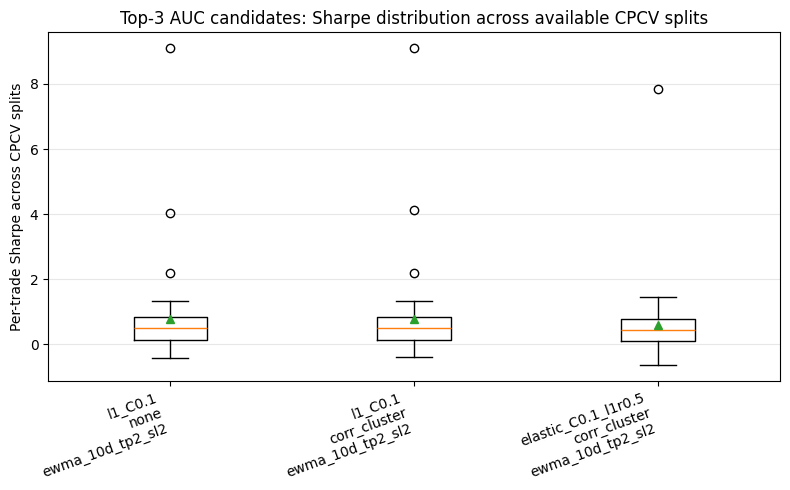

Best TB config: ewma_10d_tp2_sl2
Best logistic config: l1_C0.1
Best feature method: none
Best mean AUC: 0.5379820105920814
Best median trade Sharpe: 0.49024573201725197


In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def n_choose_k(n: int, k: int) -> int:
    """Small combinatorics helper used to explain CPCV path counts."""
    if k < 0 or k > n:
        return 0
    return int(__import__("math").comb(n, k))


def add_cpcv_path_ids(
    oof_predictions_df: pd.DataFrame,
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
) -> pd.DataFrame:
    """Stitch split/block test predictions into true CPCV paths.

    With N chronological blocks and k test blocks per CPCV model, each block is
    tested C(N-1, k-1) times. A CPCV path is built by taking the 1st test
    appearance of every block, then the 2nd appearance of every block, and so on.

    Example: N=10, k=2 gives 45 fitted models but only 9 stitched paths.
    The path Sharpe plot should use those 9 path-level returns, not all 45
    overlapping model splits as if they were independent paths.
    """
    required = {"split_id", "block_id", DATE_COL, "y_pred", "signed_touch_return"}
    missing = required - set(oof_predictions_df.columns)
    if missing:
        raise ValueError(f"OOF predictions missing columns needed for CPCV paths: {sorted(missing)}")

    expected_paths = n_choose_k(n_blocks - 1, n_test_blocks - 1)
    split_block_pairs = (
        oof_predictions_df[["split_id", "block_id"]]
        .drop_duplicates()
        .sort_values(["split_id", "block_id"])
        .reset_index(drop=True)
    )

    block_seen_counts = {block_id: 0 for block_id in range(n_blocks)}
    mapping_rows = []
    for row in split_block_pairs.itertuples(index=False):
        block_id = int(row.block_id)
        path_id = block_seen_counts[block_id]
        mapping_rows.append({
            "split_id": int(row.split_id),
            "block_id": block_id,
            "cpcv_path_id": path_id,
        })
        block_seen_counts[block_id] += 1

    bad_counts = {block: count for block, count in block_seen_counts.items() if count != expected_paths}
    if bad_counts:
        raise ValueError(
            f"CPCV path stitching expected {expected_paths} appearances per block, got {bad_counts}."
        )

    mapping_df = pd.DataFrame(mapping_rows)
    stitched = oof_predictions_df.merge(mapping_df, on=["split_id", "block_id"], how="left")
    if stitched["cpcv_path_id"].isna().any():
        raise ValueError("Some OOF rows could not be assigned to a CPCV path.")
    stitched["cpcv_path_id"] = stitched["cpcv_path_id"].astype(int)

    path_block_counts = stitched.groupby("cpcv_path_id")["block_id"].nunique()
    if not path_block_counts.eq(n_blocks).all():
        raise ValueError(f"Each CPCV path should contain all {n_blocks} blocks. Got: {path_block_counts.to_dict()}")

    return stitched.sort_values(["cpcv_path_id", DATE_COL]).reset_index(drop=True)


def compute_cpcv_path_sharpes(oof_predictions_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return path-tagged OOF predictions and one Sharpe row per stitched path."""
    stitched = add_cpcv_path_ids(oof_predictions_df)
    path_rows = []
    for path_id, path_df in stitched.groupby("cpcv_path_id"):
        accepted_returns = path_df.loc[path_df["y_pred"] == 1, "signed_touch_return"]
        path_rows.append({
            "cpcv_path_id": int(path_id),
            "n_blocks_in_path": int(path_df["block_id"].nunique()),
            "n_rows": int(len(path_df)),
            "trade_count": int((path_df["y_pred"] == 1).sum()),
            "path_trade_sharpe": per_trade_sharpe(accepted_returns),
            "mean_trade_return": accepted_returns.mean(),
        })
    path_metrics = pd.DataFrame(path_rows)
    return stitched, path_metrics


# Add true path-level Sharpe diagnostics to the AUC ranking table.
path_metric_tables = {}
path_summary_rows = []
for row in logistic_cpcv_summary.itertuples(index=False):
    key = f"{row.ticker}__{row.tb_config_name}__{row.model_name}__{row.feature_method}"
    oof_predictions = logistic_detailed_results[key]["oof_predictions"].copy()
    stitched_oof, path_metrics = compute_cpcv_path_sharpes(oof_predictions)
    logistic_detailed_results[key]["stitched_oof_predictions"] = stitched_oof
    logistic_detailed_results[key]["path_metrics"] = path_metrics
    path_metric_tables[key] = path_metrics
    path_summary_rows.append({
        "result_key": key,
        "n_cpcv_paths": int(path_metrics["cpcv_path_id"].nunique()),
        "median_path_trade_sharpe": path_metrics["path_trade_sharpe"].median(),
        "mean_path_trade_sharpe": path_metrics["path_trade_sharpe"].mean(),
        "path_sharpe_iqr": path_metrics["path_trade_sharpe"].quantile(0.75) - path_metrics["path_trade_sharpe"].quantile(0.25),
        "min_path_trade_sharpe": path_metrics["path_trade_sharpe"].min(),
        "max_path_trade_sharpe": path_metrics["path_trade_sharpe"].max(),
    })

path_summary_df = pd.DataFrame(path_summary_rows)
logistic_cpcv_summary["result_key"] = logistic_cpcv_summary.apply(
    lambda row: f"{row['ticker']}__{row['tb_config_name']}__{row['model_name']}__{row['feature_method']}",
    axis=1,
)
logistic_cpcv_summary = logistic_cpcv_summary.merge(path_summary_df, on="result_key", how="left")
logistic_cpcv_summary = logistic_cpcv_summary.sort_values(
    ["mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr"],
    ascending=[False, True, False, True],
).reset_index(drop=True)

UNIVERSAL_MODEL_COMPARISON_COLUMNS = [
    "model_type",
    "ticker",
    "tb_config_name",
    "feature_method",
    "mean_auc",
    "std_auc",
    "median_auc",
    "n_folds",
    "n_cpcv_paths",
    "median_path_trade_sharpe",
    "mean_path_trade_sharpe",
    "path_sharpe_iqr",
    "min_path_trade_sharpe",
    "max_path_trade_sharpe",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "mean_trade_count",
    "num_days",
    "model_name",
    "penalty",
    "C",
    "l1_ratio",
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "class_weight",
    "feature_params",
]


def build_universal_model_comparison(summary_df: pd.DataFrame, model_type: str = "logistic_regression") -> pd.DataFrame:
    """Create the cross-model comparison CSV schema used by all model notebooks."""
    comparison_df = summary_df.copy()
    comparison_df.insert(0, "model_type", model_type)

    # RF-only hyperparameters are intentionally blank for logistic rows.
    for col in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]:
        if col not in comparison_df.columns:
            comparison_df[col] = np.nan

    if "class_weight" not in comparison_df.columns:
        comparison_df["class_weight"] = np.nan

    if "feature_params" in comparison_df.columns:
        comparison_df["feature_params"] = comparison_df["feature_params"].apply(
            lambda value: json.dumps(value) if isinstance(value, dict) else value
        )

    missing_cols = [col for col in UNIVERSAL_MODEL_COMPARISON_COLUMNS if col not in comparison_df.columns]
    for col in missing_cols:
        comparison_df[col] = np.nan

    return comparison_df[UNIVERSAL_MODEL_COMPARISON_COLUMNS].sort_values(
        ["mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)


model_comparison_df = build_universal_model_comparison(logistic_cpcv_summary)

# Results CSVs stay compact: top 5 AUC candidates per commodity.
top5_by_auc = (
    model_comparison_df
    .sort_values(["ticker", "mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr"], ascending=[True, False, True, False, True])
    .groupby("ticker", as_index=False, group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
top3_by_auc = logistic_cpcv_summary.head(3).copy()

top5_by_auc.to_csv(LOGISTIC_RESULTS_PATH, index=False)
top5_by_auc.to_csv(MODEL_COMPARISON_RESULTS_PATH, index=False)

print("Saved top-5-by-AUC-per-commodity logistic model-comparison results to:")
print(LOGISTIC_RESULTS_PATH)
print(MODEL_COMPARISON_RESULTS_PATH)
print(
    f"CPCV setup: {CPCV_N_BLOCKS} blocks, {CPCV_N_TEST_BLOCKS} test blocks per model -> "
    f"{n_choose_k(CPCV_N_BLOCKS, CPCV_N_TEST_BLOCKS)} fitted CPCV models and "
    f"{n_choose_k(CPCV_N_BLOCKS - 1, CPCV_N_TEST_BLOCKS - 1)} stitched paths."
)

print("Top 5 AUC candidates per commodity from the universal comparison table:")
display(top5_by_auc)

# Plot Sharpe distribution across true stitched CPCV paths for the top 3 AUC candidates.
plot_rows = []
for row in top3_by_auc.itertuples(index=False):
    key = row.result_key
    path_metrics = logistic_detailed_results[key]["path_metrics"].copy()
    path_metrics["candidate"] = f"{row.ticker}\n{row.model_name}\n{row.feature_method}\n{row.tb_config_name}"
    plot_rows.append(path_metrics[["candidate", "cpcv_path_id", "path_trade_sharpe"]])

if plot_rows:
    sharpe_plot_df = pd.concat(plot_rows, ignore_index=True).dropna(subset=["path_trade_sharpe"])
    if not sharpe_plot_df.empty:
        labels = sharpe_plot_df["candidate"].drop_duplicates().tolist()
        values = [
            sharpe_plot_df.loc[sharpe_plot_df["candidate"] == label, "path_trade_sharpe"]
            for label in labels
        ]
        plt.figure(figsize=(max(8, 2.5 * len(labels)), 5))
        plt.boxplot(values, tick_labels=labels, showmeans=True)
        plt.ylabel("Per-trade Sharpe across stitched CPCV paths")
        plt.title("Top-3 AUC candidates: Sharpe distribution across true CPCV paths")
        plt.xticks(rotation=20, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("Path-level Sharpe table for top-3 AUC candidates:")
        display(sharpe_plot_df.sort_values(["candidate", "cpcv_path_id"]).reset_index(drop=True))
    else:
        print("No non-missing path Sharpe values available for top-3 plot.")

best_row = logistic_cpcv_summary.iloc[0]
BEST_RESULT_KEY = best_row["result_key"]
BEST_TB_CONFIG_NAME = best_row["tb_config_name"]
BEST_LOGISTIC_CONFIG = logistic_detailed_results[BEST_RESULT_KEY]["logistic_config"]
BEST_FEATURE_PROCESSING_CONFIG = logistic_detailed_results[BEST_RESULT_KEY]["feature_processing_config"]
BEST_TICKER = best_row["ticker"]
BEST_DATA = datasets_by_config[f"{BEST_TICKER}__{BEST_TB_CONFIG_NAME}"]

print("Best ticker:", BEST_TICKER)
print("Best TB config:", BEST_TB_CONFIG_NAME)
print("Best logistic config:", BEST_LOGISTIC_CONFIG["model_name"])
print("Best feature method:", BEST_FEATURE_PROCESSING_CONFIG["feature_method"])
print("Best mean AUC:", best_row["mean_auc"])
print("Best median stitched-path trade Sharpe:", best_row["median_path_trade_sharpe"])
print("Best stitched-path Sharpe IQR:", best_row["path_sharpe_iqr"])


## 10. Select Best Candidate Per Ticker And Estimate OOF Thresholds

After the full grid, choose the best AUC-ranked candidate separately for each energy ticker. The OOF predictions from that candidate are used to estimate an expected-value decision threshold using training-period CPCV predictions only.


EV threshold summary:


,r_G_mean_return_when_y_1,r_L_mean_return_when_y_0,raw_threshold,clipped_threshold,threshold_valid,n_good,n_bad,bootstrap_threshold_median,bootstrap_threshold_5pct,bootstrap_threshold_95pct
0,0.072771,-0.064981,0.471725,0.471725,True,221,112,0.472052,0.4316,0.512155


Chosen EV threshold: 0.4717248032803858


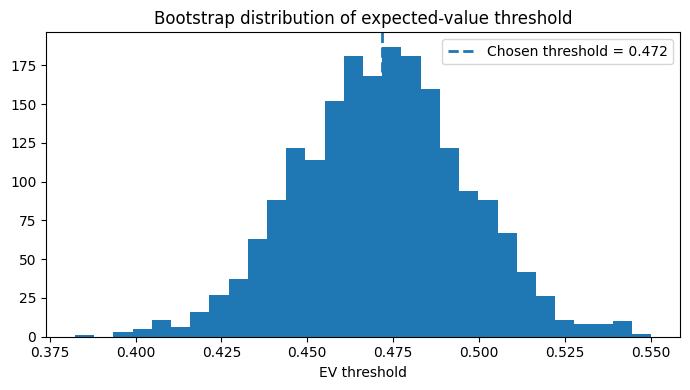

In [ ]:
def average_oof_predictions(oof_predictions_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = [DATE_COL]
    if INSTRUMENT_COL in oof_predictions_df.columns:
        group_cols.append(INSTRUMENT_COL)
    return (
        oof_predictions_df
        .groupby(group_cols, as_index=False)
        .agg(
            primary_signal=("primary_signal", "first"),
            y_true=("y_true", "first"),
            y_proba=("y_proba", "mean"),
            signed_touch_return=("signed_touch_return", "first"),
            n_oof_predictions=("y_proba", "size"),
        )
    )


def estimate_ev_threshold(train_eval_df: pd.DataFrame, n_bootstrap: int = 2000) -> tuple[dict, pd.DataFrame]:
    rng = np.random.default_rng(RANDOM_STATE)
    df = train_eval_df[["y_true", "signed_touch_return"]].dropna().copy()
    df["y_true"] = df["y_true"].astype(int)

    good_returns = df.loc[df["y_true"] == 1, "signed_touch_return"].to_numpy()
    bad_returns = df.loc[df["y_true"] == 0, "signed_touch_return"].to_numpy()
    if len(good_returns) == 0 or len(bad_returns) == 0:
        summary = {
            "r_G_mean_return_when_y_1": np.nan,
            "r_L_mean_return_when_y_0": np.nan,
            "raw_threshold": np.nan,
            "clipped_threshold": 0.5,
            "threshold_valid": False,
            "n_good": len(good_returns),
            "n_bad": len(bad_returns),
            "bootstrap_threshold_median": np.nan,
            "bootstrap_threshold_5pct": np.nan,
            "bootstrap_threshold_95pct": np.nan,
        }
        return summary, pd.DataFrame()

    r_G = float(np.mean(good_returns))
    r_L = float(np.mean(bad_returns))
    denominator = r_G - r_L
    if denominator <= 0:
        raw_threshold = np.nan
        clipped_threshold = 0.5
        threshold_valid = False
    else:
        raw_threshold = -r_L / denominator
        clipped_threshold = float(np.clip(raw_threshold, 0.0, 1.0))
        threshold_valid = np.isfinite(raw_threshold)

    bootstrap_rows = []
    for i in range(n_bootstrap):
        boot_good = rng.choice(good_returns, size=len(good_returns), replace=True)
        boot_bad = rng.choice(bad_returns, size=len(bad_returns), replace=True)
        boot_r_G = float(np.mean(boot_good))
        boot_r_L = float(np.mean(boot_bad))
        boot_denom = boot_r_G - boot_r_L
        boot_threshold = -boot_r_L / boot_denom if boot_denom > 0 else np.nan
        bootstrap_rows.append({
            "bootstrap_id": i + 1,
            "r_G": boot_r_G,
            "r_L": boot_r_L,
            "raw_threshold": boot_threshold,
            "clipped_threshold": float(np.clip(boot_threshold, 0.0, 1.0)) if np.isfinite(boot_threshold) else np.nan,
        })

    bootstrap_df = pd.DataFrame(bootstrap_rows)
    summary = {
        "r_G_mean_return_when_y_1": r_G,
        "r_L_mean_return_when_y_0": r_L,
        "raw_threshold": raw_threshold,
        "clipped_threshold": clipped_threshold,
        "threshold_valid": threshold_valid,
        "n_good": len(good_returns),
        "n_bad": len(bad_returns),
        "bootstrap_threshold_median": bootstrap_df["clipped_threshold"].median(),
        "bootstrap_threshold_5pct": bootstrap_df["clipped_threshold"].quantile(0.05),
        "bootstrap_threshold_95pct": bootstrap_df["clipped_threshold"].quantile(0.95),
    }
    return summary, bootstrap_df


best_by_ticker = (
    logistic_cpcv_summary
    .sort_values(["ticker", "mean_auc", "std_auc", "median_path_trade_sharpe", "path_sharpe_iqr"], ascending=[True, False, True, False, True])
    .groupby("ticker", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

threshold_rows = []
threshold_bootstrap_by_ticker = {}
avg_oof_by_ticker = {}

for row in best_by_ticker.itertuples(index=False):
    result_key = row.result_key
    best_oof_predictions = logistic_detailed_results[result_key]["oof_predictions"]
    avg_oof_predictions = average_oof_predictions(best_oof_predictions)
    threshold_summary, threshold_bootstrap_df = estimate_ev_threshold(avg_oof_predictions)
    threshold_summary = {"ticker": row.ticker, "result_key": result_key, **threshold_summary}
    threshold_rows.append(threshold_summary)
    threshold_bootstrap_by_ticker[row.ticker] = threshold_bootstrap_df
    avg_oof_by_ticker[row.ticker] = avg_oof_predictions

threshold_summary_df = pd.DataFrame(threshold_rows)

print("Best AUC candidate per ticker:")
display_cols = [
    "ticker", "tb_config_name", "model_name", "feature_method", "mean_auc", "std_auc",
    "n_cpcv_paths", "median_path_trade_sharpe", "path_sharpe_iqr", "result_key",
]
display(best_by_ticker[display_cols])

print("OOF EV thresholds per ticker:")
display(threshold_summary_df)


## 11. Final Fit And OOS Evaluation Per Ticker

For each ticker, refit its selected best candidate on all pre-2022 rows and evaluate on the OOS rows. This mirrors the Random Forest notebook, but repeats the final fit once per energy ticker.


In [ ]:
def fit_final_logistic_for_result(result_key: str, ev_threshold: float) -> dict:
    detail = logistic_detailed_results[result_key]
    ticker = detail["ticker"]
    tb_config_name = detail["tb_config_name"]
    data = datasets_by_config[detail["dataset_key"]]
    logistic_config = detail["logistic_config"]
    feature_processing_config = detail["feature_processing_config"]

    final_train_df = data["train_df"].copy()
    final_test_df = data["test_df"].copy()
    if final_test_df.empty:
        raise ValueError(
            f"OOS test set is empty for {ticker}/{tb_config_name}. Regenerate triple-barrier labels "
            "with training_end=None or choose a test period covered by the label CSVs."
        )

    y_final_train = final_train_df[TARGET_COL].astype(int)
    y_oos = final_test_df[TARGET_COL].astype(int)

    X_final_processed, X_oos_processed, final_processed_feature_cols, final_processing_info = apply_feature_processing_for_fold(
        fold_train=final_train_df,
        fold_test=final_test_df,
        feature_cols=data["feature_cols"],
        y_fold_train=y_final_train,
        feature_processing_config=feature_processing_config,
    )

    final_preprocessor = fit_logistic_preprocessor(X_final_processed)
    X_final_scaled = final_preprocessor["X_train_scaled"]
    X_oos_scaled = transform_logistic_features(X_oos_processed, final_preprocessor)

    final_logistic_model = make_logistic_model(logistic_config["model_params"])
    with warnings.catch_warnings(record=True) as final_warnings:
        warnings.simplefilter("always", ConvergenceWarning)
        warnings.simplefilter("always", RuntimeWarning)
        final_logistic_model.fit(X_final_scaled, y_final_train)

    oos_proba = get_positive_class_proba(final_logistic_model, X_oos_scaled)

    oos_predictions_df = final_test_df[[DATE_COL, INSTRUMENT_COL, "primary_signal", TARGET_COL, "signed_touch_return"]].copy()
    oos_predictions_df = oos_predictions_df.rename(columns={TARGET_COL: "y_true"})
    oos_predictions_df["ticker"] = ticker
    oos_predictions_df["tb_config_name"] = tb_config_name
    oos_predictions_df["model_name"] = logistic_config["model_name"]
    oos_predictions_df["feature_method"] = feature_processing_config["feature_method"]
    oos_predictions_df["y_proba"] = oos_proba
    oos_predictions_df["ev_threshold"] = ev_threshold
    oos_predictions_df["y_pred_0_5"] = (oos_predictions_df["y_proba"] >= 0.5).astype(int)
    oos_predictions_df["y_pred_ev"] = (oos_predictions_df["y_proba"] >= ev_threshold).astype(int)

    oos_metrics_05 = classification_metrics(oos_predictions_df["y_true"], oos_predictions_df["y_proba"], threshold=0.5)
    oos_metrics_ev = classification_metrics(oos_predictions_df["y_true"], oos_predictions_df["y_proba"], threshold=ev_threshold)

    return {
        "ticker": ticker,
        "tb_config_name": tb_config_name,
        "result_key": result_key,
        "logistic_config": logistic_config,
        "feature_processing_config": feature_processing_config,
        "data": data,
        "final_train_df": final_train_df,
        "final_test_df": final_test_df,
        "final_logistic_model": final_logistic_model,
        "final_preprocessor": final_preprocessor,
        "final_processing_info": final_processing_info,
        "final_processed_feature_cols": final_processed_feature_cols,
        "oos_predictions_df": oos_predictions_df,
        "oos_metrics_05": oos_metrics_05,
        "oos_metrics_ev": oos_metrics_ev,
        "final_warning_count": len(final_warnings),
    }


final_results_by_ticker = {}
oos_metric_rows = []

for row in best_by_ticker.itertuples(index=False):
    threshold_row = threshold_summary_df.loc[threshold_summary_df["ticker"] == row.ticker].iloc[0]
    ev_threshold = float(threshold_row["clipped_threshold"])
    result = fit_final_logistic_for_result(row.result_key, ev_threshold)
    final_results_by_ticker[row.ticker] = result

    oos_metric_rows.append({
        "ticker": row.ticker,
        "threshold": "0.5",
        "final_warning_count": result["final_warning_count"],
        **result["oos_metrics_05"],
    })
    oos_metric_rows.append({
        "ticker": row.ticker,
        "threshold": "ev",
        "ev_threshold": ev_threshold,
        "final_warning_count": result["final_warning_count"],
        **result["oos_metrics_ev"],
    })

oos_metrics_df = pd.DataFrame(oos_metric_rows)
print("OOS metrics per ticker:")
display(oos_metrics_df)


Final fit warnings: 0
OOS rows: 78
OOS metrics at threshold 0.5:


,accuracy,precision,recall,f1,brier,log_loss,auc,tn,fp,fn,tp
0,0.74359,0.854839,0.828125,0.84127,0.182093,0.54765,0.646205,5,9,11,53


OOS metrics at EV threshold 0.4717:


,accuracy,precision,recall,f1,brier,log_loss,auc,tn,fp,fn,tp
0,0.75641,0.846154,0.859375,0.852713,0.182093,0.54765,0.646205,4,10,9,55


,date,instrument,primary_signal,y_true,signed_touch_return,y_proba,y_pred_0_5,y_pred_ev
333,2022-01-03,cl1s,1,1,0.067560,0.717293,1,1
334,2022-01-04,cl1s,1,1,0.054942,0.712575,1,1
335,2022-01-05,cl1s,1,1,0.061529,0.709792,1,1
336,2022-01-06,cl1s,1,1,0.054748,0.719279,1,1
337,2022-01-07,cl1s,1,1,0.062234,0.712292,1,1


## 12. Primary Baseline And Confusion Matrices

Compare each ticker's selected logistic meta-filter against blindly taking every primary signal in the OOS period.


Primary-alone baseline metrics:


,accuracy,precision,recall,f1
0,0.820513,0.820513,1.0,0.901408


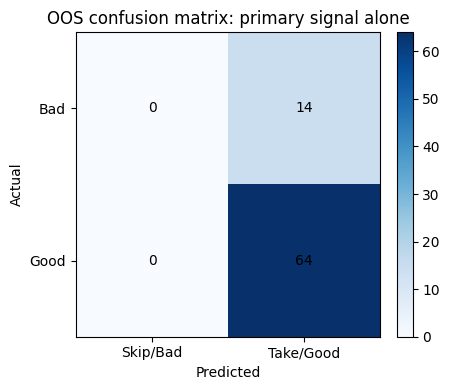

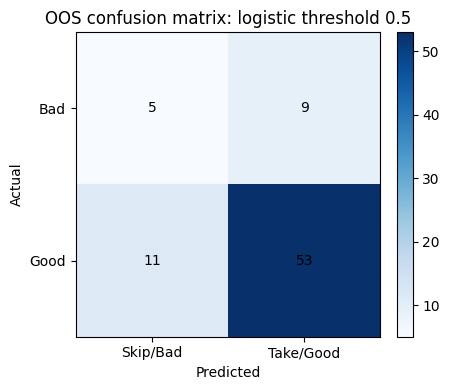

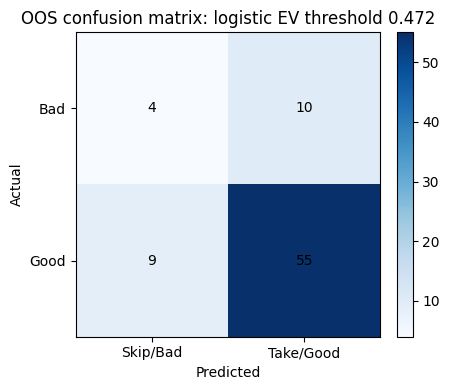

In [ ]:
def plot_confusion_matrix_from_labels(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Skip/Bad", "Take/Good"])
    ax.set_yticklabels(["Bad", "Good"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


baseline_metric_rows = []
for ticker, result in final_results_by_ticker.items():
    preds = result["oos_predictions_df"]
    preds["primary_baseline_pred"] = 1
    baseline_metric_rows.append({
        "ticker": ticker,
        "accuracy": accuracy_score(preds["y_true"], preds["primary_baseline_pred"]),
        "precision": precision_score(preds["y_true"], preds["primary_baseline_pred"], zero_division=0),
        "recall": recall_score(preds["y_true"], preds["primary_baseline_pred"], zero_division=0),
        "f1": f1_score(preds["y_true"], preds["primary_baseline_pred"], zero_division=0),
    })

baseline_metrics_df = pd.DataFrame(baseline_metric_rows)
print("Primary-alone baseline metrics per ticker:")
display(baseline_metrics_df)

# Keep plots concise: plot confusion matrices for each ticker's selected EV threshold.
for ticker, result in final_results_by_ticker.items():
    preds = result["oos_predictions_df"]
    threshold = float(preds["ev_threshold"].iloc[0])
    plot_confusion_matrix_from_labels(
        preds["y_true"],
        preds["primary_baseline_pred"],
        f"{ticker}: OOS confusion matrix, primary signal alone",
    )
    plot_confusion_matrix_from_labels(
        preds["y_true"],
        preds["y_pred_ev"],
        f"{ticker}: OOS confusion matrix, logistic EV threshold {threshold:.3f}",
    )


## 13. Strategy Diagnostics Per Ticker

Build the same primary-alone versus meta-filter strategy comparison as the RF notebook, once for each energy ticker.


In [ ]:
def build_strategy_analysis(predictions_df: pd.DataFrame, horizon_days: int, threshold: float):
    strategy_df = predictions_df.copy().dropna(subset=["signed_touch_return"]).sort_values(DATE_COL).reset_index(drop=True)
    strategy_df["meta_take_trade"] = (strategy_df["y_proba"] >= threshold).astype(int)
    strategy_df["primary_return"] = strategy_df["signed_touch_return"]
    strategy_df["meta_return"] = strategy_df["meta_take_trade"] * strategy_df["signed_touch_return"]
    strategy_df["primary_nav"] = (1.0 + strategy_df["primary_return"]).cumprod()
    strategy_df["meta_nav"] = (1.0 + strategy_df["meta_return"]).cumprod()

    periods_per_year = 252 / horizon_days
    summary_df = pd.DataFrame([
        {
            "strategy": "Primary alone",
            "n_trades_taken": int(len(strategy_df)),
            "trade_rate": 1.0,
            "mean_event_return": strategy_df["primary_return"].mean(),
            "total_profit_pct": strategy_df["primary_nav"].iloc[-1] - 1.0,
            "annualised_sharpe": annualised_sharpe(strategy_df["primary_return"], periods_per_year),
            "max_drawdown": max_drawdown(strategy_df["primary_nav"]),
        },
        {
            "strategy": "Primary + logistic meta filter",
            "n_trades_taken": int(strategy_df["meta_take_trade"].sum()),
            "trade_rate": float(strategy_df["meta_take_trade"].mean()),
            "mean_event_return": strategy_df["meta_return"].mean(),
            "total_profit_pct": strategy_df["meta_nav"].iloc[-1] - 1.0,
            "annualised_sharpe": annualised_sharpe(strategy_df["meta_return"], periods_per_year),
            "max_drawdown": max_drawdown(strategy_df["meta_nav"]),
        },
    ])
    return strategy_df, summary_df


def plot_nav_comparison(strategy_df: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    plt.plot(strategy_df[DATE_COL], strategy_df["primary_nav"], label="Primary alone")
    plt.plot(strategy_df[DATE_COL], strategy_df["meta_nav"], label="Primary + logistic meta filter")
    plt.xlabel("Date")
    plt.ylabel("NAV")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


strategy_summary_tables = []
for ticker, result in final_results_by_ticker.items():
    data = result["data"]
    threshold = float(result["oos_predictions_df"]["ev_threshold"].iloc[0])
    strategy_df, strategy_summary_df = build_strategy_analysis(
        predictions_df=result["oos_predictions_df"],
        horizon_days=data["num_days"],
        threshold=threshold,
    )
    strategy_df["ticker"] = ticker
    strategy_summary_df.insert(0, "ticker", ticker)
    result["oos_strategy_df"] = strategy_df
    result["oos_strategy_summary_df"] = strategy_summary_df
    strategy_summary_tables.append(strategy_summary_df)

    plot_nav_comparison(strategy_df, f"{ticker}: OOS NAV, primary alone vs logistic meta filter, threshold={threshold:.3f}")

oos_strategy_summary_all_df = pd.concat(strategy_summary_tables, ignore_index=True)
print("OOS strategy comparison per ticker:")
display(oos_strategy_summary_all_df)


## 14. Feature And Cluster Importance Per Ticker

For logistic regression, RF-comparable `importance` is the absolute standardized coefficient. The signed coefficient is retained because direction still matters.


In [ ]:
def build_logistic_feature_importance(result: dict) -> pd.DataFrame:
    coef_df = pd.DataFrame({
        "feature": result["final_processed_feature_cols"],
        "coefficient": result["final_logistic_model"].coef_.ravel(),
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    feature_importance_df = coef_df.assign(
        importance=coef_df["abs_coefficient"],
        importance_type="abs_standardized_logistic_coefficient",
    )[["feature", "importance", "coefficient", "abs_coefficient", "importance_type"]]
    return feature_importance_df


def build_cluster_importance_df(feature_importance_df: pd.DataFrame, processing_info: dict) -> pd.DataFrame:
    method = processing_info.get("feature_method", "none")
    importance_df = feature_importance_df.copy()
    importance_df["importance_group"] = importance_df["feature"]
    importance_df["group_type"] = "single_feature"
    importance_df["cluster_id"] = np.nan
    importance_df["cluster_n_features"] = 1
    importance_df["cluster_features"] = importance_df["feature"].apply(lambda x: [x])
    importance_df["dropped_cluster_features"] = [[] for _ in range(len(importance_df))]

    if method == "corr_cluster":
        selector = processing_info.get("processor")
        if selector is not None and hasattr(selector, "cluster_summary_"):
            cluster_summary = selector.cluster_summary_.copy()
            if not cluster_summary.empty:
                rep_to_group = {}
                rep_to_cluster_id = {}
                rep_to_n_features = {}
                rep_to_cluster_features = {}
                rep_to_dropped_features = {}
                for row in cluster_summary.itertuples(index=False):
                    cluster_id = int(row.cluster_id)
                    representative = row.representative_feature
                    cluster_features = list(row.cluster_features)
                    dropped_features = list(row.dropped_features)
                    rep_to_group[representative] = f"cluster_{cluster_id:03d}: {representative} (rep, n={len(cluster_features)})"
                    rep_to_cluster_id[representative] = cluster_id
                    rep_to_n_features[representative] = len(cluster_features)
                    rep_to_cluster_features[representative] = cluster_features
                    rep_to_dropped_features[representative] = dropped_features
                is_cluster_rep = importance_df["feature"].isin(rep_to_group.keys())
                importance_df.loc[is_cluster_rep, "importance_group"] = importance_df.loc[is_cluster_rep, "feature"].map(rep_to_group)
                importance_df.loc[is_cluster_rep, "group_type"] = "correlation_cluster"
                importance_df.loc[is_cluster_rep, "cluster_id"] = importance_df.loc[is_cluster_rep, "feature"].map(rep_to_cluster_id)
                importance_df.loc[is_cluster_rep, "cluster_n_features"] = importance_df.loc[is_cluster_rep, "feature"].map(rep_to_n_features)
                importance_df.loc[is_cluster_rep, "cluster_features"] = importance_df.loc[is_cluster_rep, "feature"].map(rep_to_cluster_features)
                importance_df.loc[is_cluster_rep, "dropped_cluster_features"] = importance_df.loc[is_cluster_rep, "feature"].map(rep_to_dropped_features)
    elif method == "pca":
        importance_df["group_type"] = np.where(importance_df["feature"].str.startswith("pca_"), "pca_component", "single_feature")

    cluster_df = (
        importance_df
        .groupby("importance_group", as_index=False)
        .agg(
            cluster_importance=("importance", "sum"),
            group_type=("group_type", "first"),
            representative_model_features=("feature", lambda x: list(x)),
            n_model_features=("feature", "count"),
            cluster_id=("cluster_id", "first"),
            cluster_n_features=("cluster_n_features", "first"),
            cluster_features=("cluster_features", "first"),
            dropped_cluster_features=("dropped_cluster_features", "first"),
        )
        .sort_values("cluster_importance", ascending=False)
        .reset_index(drop=True)
    )
    cluster_df["importance_type"] = "sum_abs_standardized_logistic_coefficients"
    return cluster_df


feature_importance_tables = []
cluster_importance_tables = []
for ticker, result in final_results_by_ticker.items():
    feature_importance_df = build_logistic_feature_importance(result)
    cluster_importance_df = build_cluster_importance_df(feature_importance_df, result["final_processing_info"])
    feature_importance_df.insert(0, "ticker", ticker)
    cluster_importance_df.insert(0, "ticker", ticker)
    result["feature_importance_df"] = feature_importance_df
    result["cluster_importance_df"] = cluster_importance_df
    feature_importance_tables.append(feature_importance_df)
    cluster_importance_tables.append(cluster_importance_df)

feature_importance_all_df = pd.concat(feature_importance_tables, ignore_index=True)
cluster_importance_all_df = pd.concat(cluster_importance_tables, ignore_index=True)

print("Top logistic feature importance per ticker:")
display(feature_importance_all_df.groupby("ticker").head(10))
print("Top logistic cluster/component importance per ticker:")
display(cluster_importance_all_df.groupby("ticker").head(10))


Top positive coefficients:


,feature,coefficient,abs_coefficient
0,vol_ratio_63_126d,0.740838,0.740838
1,macd_hist,0.357168,0.357168
2,open_interest_zscore_20d,0.224989,0.224989
4,bb_width_zscore,0.132444,0.132444
7,vol_252d,0.091236,0.091236
9,volume_zscore_20d,0.070614,0.070614
100,mom_sign_20d,0.000000,0.000000
94,price_vs_sma5,0.000000,0.000000
95,ret_spread_20_63,0.000000,0.000000
96,ret_spread_5_20,0.000000,0.000000


Top negative coefficients:


,feature,coefficient,abs_coefficient
3,zscore_63d,-0.191911,0.191911
5,vol_5d,-0.119478,0.119478
6,close,-0.106153,0.106153
8,ret_126d,-0.075132,0.075132
10,hmm_prob_calm_positive,-0.050878,0.050878
11,open_interest_log_change,-0.039358,0.039358
12,macd_hist_chg,-0.037659,0.037659
13,ret_1d,-0.031459,0.031459
95,ret_spread_20_63,0.000000,0.000000
96,ret_spread_5_20,0.000000,0.000000


primary_signal coefficient:


,feature,coefficient,abs_coefficient
21,primary_signal,0.0,0.0


Metalabel success rate by primary signal in training data:


,count,mean
primary_signal,,
-1,26,0.500000
1,307,0.677524


Top cluster/component coefficient importance:


,importance_group,cluster_abs_coefficient,net_coefficient,group_type,representative_model_features,n_model_features,cluster_id,cluster_n_features,cluster_features
0,vol_ratio_63_126d,0.740838,0.740838,single_feature,[vol_ratio_63_126d],1,NaN,1,[vol_ratio_63_126d]
1,macd_hist,0.357168,0.357168,single_feature,[macd_hist],1,NaN,1,[macd_hist]
2,open_interest_zscore_20d,0.224989,0.224989,single_feature,[open_interest_zscore_20d],1,NaN,1,[open_interest_zscore_20d]
3,zscore_63d,0.191911,-0.191911,single_feature,[zscore_63d],1,NaN,1,[zscore_63d]
4,bb_width_zscore,0.132444,0.132444,single_feature,[bb_width_zscore],1,NaN,1,[bb_width_zscore]
5,vol_5d,0.119478,-0.119478,single_feature,[vol_5d],1,NaN,1,[vol_5d]
6,close,0.106153,-0.106153,single_feature,[close],1,NaN,1,[close]
7,vol_252d,0.091236,0.091236,single_feature,[vol_252d],1,NaN,1,[vol_252d]
8,ret_126d,0.075132,-0.075132,single_feature,[ret_126d],1,NaN,1,[ret_126d]
9,volume_zscore_20d,0.070614,0.070614,single_feature,[volume_zscore_20d],1,NaN,1,[volume_zscore_20d]


## 15. Save RF-Style Logistic Outputs Per Ticker

Each ticker gets the same output categories as the Random Forest notebook: CPCV summary, OOS predictions, OOS strategy returns, OOS strategy summary, feature importance, and cluster/component importance.


In [ ]:
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Universal comparison table for reporting: top 5 AUC candidates per commodity.
top5_by_auc.to_csv(LOGISTIC_RESULTS_PATH, index=False)
top5_by_auc.to_csv(MODEL_COMPARISON_RESULTS_PATH, index=False)

saved_paths = [LOGISTIC_RESULTS_PATH, MODEL_COMPARISON_RESULTS_PATH]

for ticker, result in final_results_by_ticker.items():
    ticker_summary = logistic_cpcv_summary[logistic_cpcv_summary["ticker"] == ticker].copy()

    CPCV_SUMMARY_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_cpcv_summary.csv"
    OOS_PREDICTIONS_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_oos_predictions.csv"
    OOS_STRATEGY_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_oos_strategy_returns.csv"
    OOS_STRATEGY_SUMMARY_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_oos_strategy_summary.csv"
    FEATURE_IMPORTANCE_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_feature_importance.csv"
    CLUSTER_IMPORTANCE_PATH = MODEL_OUTPUT_DIR / f"{ticker}_logistic_cluster_importance.csv"

    ticker_summary.to_csv(CPCV_SUMMARY_PATH, index=False)
    result["oos_predictions_df"].to_csv(OOS_PREDICTIONS_PATH, index=False)
    result["oos_strategy_df"].to_csv(OOS_STRATEGY_PATH, index=False)
    result["oos_strategy_summary_df"].to_csv(OOS_STRATEGY_SUMMARY_PATH, index=False)
    result["feature_importance_df"].to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    result["cluster_importance_df"].to_csv(CLUSTER_IMPORTANCE_PATH, index=False)

    saved_paths.extend([
        CPCV_SUMMARY_PATH,
        OOS_PREDICTIONS_PATH,
        OOS_STRATEGY_PATH,
        OOS_STRATEGY_SUMMARY_PATH,
        FEATURE_IMPORTANCE_PATH,
        CLUSTER_IMPORTANCE_PATH,
    ])

print("Saved logistic outputs with the same structure as the Random Forest notebook:")
for path in saved_paths:
    print(path)
